# CAB420 Assignment 1A Question 1: Template
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 1. It implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [10]:
import pandas
import numpy

In [11]:
# load data
train = pandas.read_csv('Q1/communities_train.csv')
val = pandas.read_csv('Q1/communities_val.csv')
test = pandas.read_csv('Q1/communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
X_train = train.iloc[:,0:-1]
y_train = train.iloc[:,-1]
X_val = val.iloc[:,0:-1]
y_val = val.iloc[:,-1]
X_test = test.iloc[:,0:-1]
y_test = test.iloc[:,-1]

In [12]:
# If you wish to pre-process the data, do so here. In your write-up, outline why you choose to do, or choose not to do, any
# pre-processing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("TRAIN RMSE:", rmse(y_train, y_train_pred))
print("VAL RMSE:", rmse(y_val, y_val_pred))
print("TEST RMSE:", rmse(y_test, y_test_pred))

print("TRAIN R2:", r2_score(y_train, y_train_pred))
print("VAL R2:", r2_score(y_val, y_val_pred))
print("TEST R2:", r2_score(y_test, y_test_pred))

TRAIN RMSE: 0.10419990101033946
VAL RMSE: 0.15491210066258168
TEST RMSE: 0.15329167324790252
TRAIN R2: 0.759085121509442
VAL R2: 0.6209292488246203
TEST R2: 0.5530667409619374


In [19]:
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#

# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the 
#    distribution of the residuals
# Your write-up should include your findings regarding the above.
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 2, 25)

ridge_results = []
lasso_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    ridge_results.append(rmse(y_val, y_val_pred))

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_val_pred = lasso.predict(X_val)
    lasso_results.append(rmse(y_val, y_val_pred))

In [20]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested 
# starting point for finding your value of lambda is suggested below using numpy.logspace (see 
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and 
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of 
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas. 
#
alphas = np.logspace(-3, 2, 25)
# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.
best_ridge_alpha = alphas[np.argmin(ridge_results)]
best_lasso_alpha = alphas[np.argmin(lasso_results)]

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Lasso alpha:", best_lasso_alpha)

ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

print("\nLinear Regression")
print("TRAIN RMSE:", rmse(y_train, model.predict(X_train)))
print("VAL RMSE:", rmse(y_val, model.predict(X_val)))
print("TEST RMSE:", rmse(y_test, model.predict(X_test)))

print("TRAIN R2:", r2_score(y_train, model.predict(X_train)))
print("VAL R2:", r2_score(y_val, model.predict(X_val)))
print("TEST R2:", r2_score(y_test, model.predict(X_test)))


print("\nRidge Regression")
print("TRAIN RMSE:", rmse(y_train, ridge.predict(X_train)))
print("VAL RMSE:", rmse(y_val, ridge.predict(X_val)))
print("TEST RMSE:", rmse(y_test, ridge.predict(X_test)))

print("TRAIN R2:", r2_score(y_train, ridge.predict(X_train)))
print("VAL R2:", r2_score(y_val, ridge.predict(X_val)))
print("TEST R2:", r2_score(y_test, ridge.predict(X_test)))


print("\nLasso Regression")
print("TRAIN RMSE:", rmse(y_train, lasso.predict(X_train)))
print("VAL RMSE:", rmse(y_val, lasso.predict(X_val)))
print("TEST RMSE:", rmse(y_test, lasso.predict(X_test)))

print("TRAIN R2:", r2_score(y_train, lasso.predict(X_train)))
print("VAL R2:", r2_score(y_val, lasso.predict(X_val)))
print("TEST R2:", r2_score(y_test, lasso.predict(X_test)))

Best Ridge alpha: 0.825404185268019
Best Lasso alpha: 0.001

Linear Regression
TRAIN RMSE: 0.10419990101033946
VAL RMSE: 0.15491210066258168
TEST RMSE: 0.15329167324790252
TRAIN R2: 0.759085121509442
VAL R2: 0.6209292488246203
TEST R2: 0.5530667409619374

Ridge Regression
TRAIN RMSE: 0.11327932313533687
VAL RMSE: 0.1421918799894199
TEST RMSE: 0.12975940750861448
TRAIN R2: 0.7152719196652083
VAL R2: 0.6806262761799574
TEST R2: 0.679754340231669

Lasso Regression
TRAIN RMSE: 0.12298967373008322
VAL RMSE: 0.14540291264180313
TEST RMSE: 0.1298802159676962
TRAIN R2: 0.66436572226458
VAL R2: 0.6660389622445211
TEST R2: 0.6791577531288793


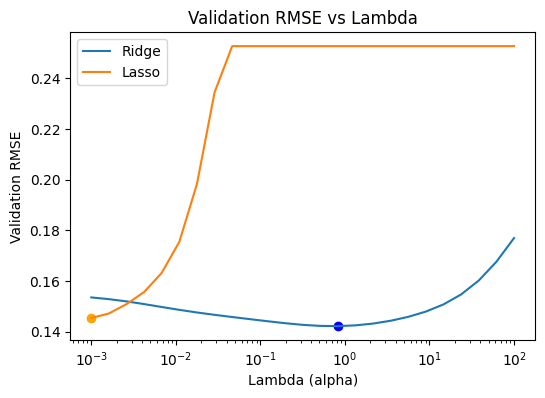

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(alphas, ridge_results, label='Ridge')
plt.plot(alphas, lasso_results, label='Lasso')

plt.scatter(best_ridge_alpha, min(ridge_results), color='blue')
plt.scatter(best_lasso_alpha, min(lasso_results), color='orange')

plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Validation RMSE')
plt.title('Validation RMSE vs Lambda')
plt.legend()
plt.savefig("lambda_rmse_plot.png", dpi=300, bbox_inches='tight')
plt.show()

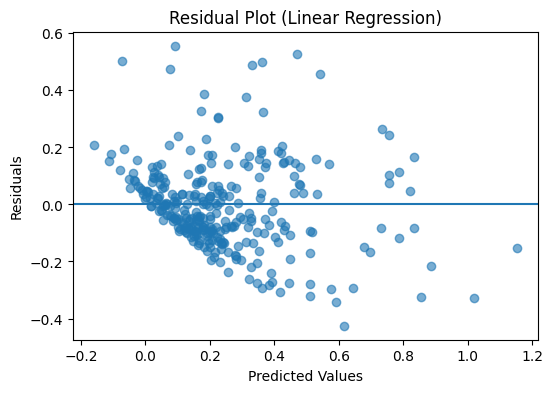

In [22]:
# Residuals for Linear Regression
residuals = y_test - model.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(model.predict(X_test), residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.savefig("residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

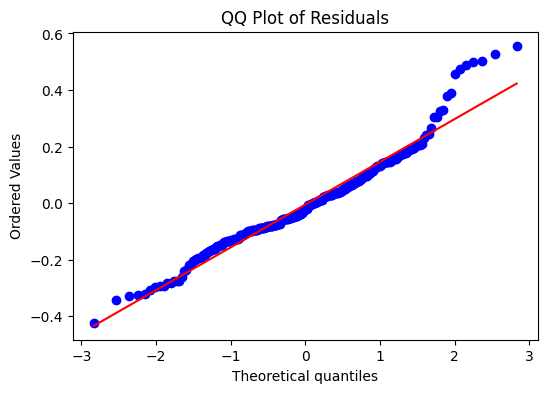

In [17]:
import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.savefig("qq_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the values of lambda used in your regularised models, and what those values are
# - a comparison of three models, considering both the accuracy and validity of the models, as outlined above, this means:
#   > accuracy of the model
#   > measures of fit, such as R^2
#   > testing assumptions about the independence of predictors, and the distribution of the residuals
# - A discussion of the ethical concerns that need to be considered when evaluating the models developed for this problem
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions. 
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT